# 3.  Codificación de variables

Conjunto de datos: titanic (incluido en seaborn)

Este conjunto de datos es excelente para trabajar con variables categóricas.

In [8]:
# Importar librerías necesarias
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import matplotlib.pyplot as plt

In [2]:
# Cargar el conjunto de datos
data = sns.load_dataset('titanic')

In [3]:
# Visualizar las primeras filas
print("Conjunto de datos Titanic:")
data.head()

Conjunto de datos Titanic:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [7]:
# Seleccionar columnas categóricas
categorical_cols = ['sex', 'embarked', 'class']

In [5]:
# Codificar con LabelEncoder
label_encoder = LabelEncoder()
data['sex_label'] = label_encoder.fit_transform(data['sex'])

In [6]:
# Codificar con OneHotEncoder
onehot_encoder = pd.get_dummies(data['embarked'], prefix='embarked')

In [8]:
# Combinar con el conjunto original
data = pd.concat([data, onehot_encoder], axis=1)

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre LabelEncoder y OneHotEncoder?

In [ ]:
#la diferencia radica en como el modelo interpreta la importancia de los datos
#label encodder: asigna un numero entero a cada cateogira, su mayor riesgo puede pensar que hay un orden de importancia
#onehot encoder: crea una columna nueva por cada categoria y pone un 1 o 0, su ventaja es que elimina cualquier jeracquia falsa ya que no hay un rango solo la presencia o ausencia de una caracteristica

### 2. Crea una gráfica de barras comparando las frecuencias de 'sex' antes y después de la codificación con LabelEncoder.

C:\Users\lordb\AppData\Local\Temp\ipykernel_9780\103616844.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex', data=data, ax=axes[0], palette='pastel')
C:\Users\lordb\AppData\Local\Temp\ipykernel_9780\103616844.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex_label', data=data, ax=axes[1], palette='magma')


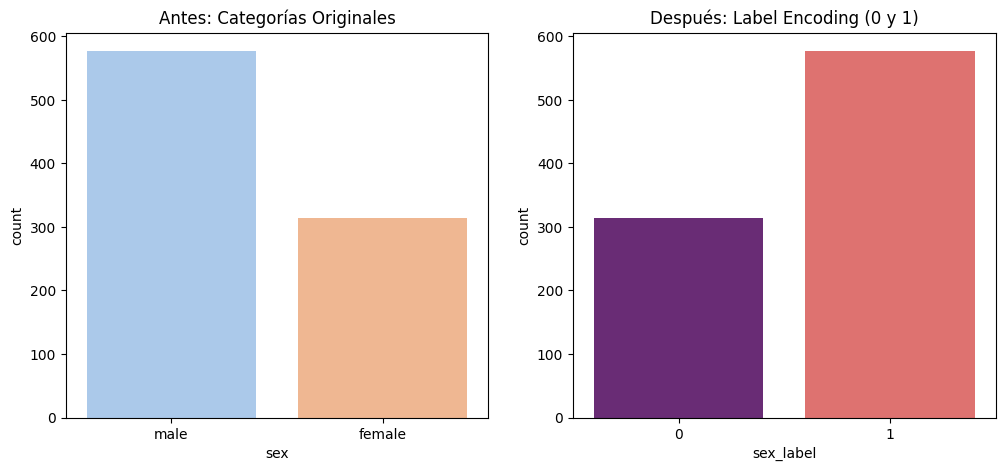

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='sex', data=data, ax=axes[0], palette='pastel')
axes[0].set_title('Antes: Categorías Originales')

sns.countplot(x='sex_label', data=data, ax=axes[1], palette='magma')
axes[1].set_title('Después: Label Encoding (0 y 1)')

plt.show()

### 3. Utiliza OneHotEncoder para codificar la columna 'class'. ¿Qué ventajas tiene este enfoque frente a LabelEncoder?

In [10]:
class_onehot = pd.get_dummies(data['class'], prefix='class')

data = pd.concat([data, class_onehot], axis=1)

print("Nuevas columnas generadas:")
print(class_onehot.head())

Nuevas columnas generadas:
   class_First  class_Second  class_Third
0        False         False         True
1         True         False        False
2        False         False         True
3         True         False        False
4        False         False         True


### 4. Si quisieras aplicar un modelo de aprendizaje automático, ¿qué tipo de codificación elegirías para las variables categóricas? Explica tu respuesta.

In [ ]:
#dependera de si la variable tiene un orden logivo, ordinal o no nominal, para un modelo de aprendizaje automatico con el dataset del titanica
#escogeria el on-hot encoding para que estas columnas porque no existe un orden jeraquico entre ser hombre o mujer o entre embarcar en southampton o cherbourg
#con esto aseguramos que el modelo trate cada categoria de forma independiente y equitativa permitiendole descubrir patrones de supervivenncia basaddos en la presencia o ausencia de las caracteristicas sin imponer una jerarquia numerica
